# Test Model
This notebook tests the `mithai_model_best.pth` model on the images in the `test` directory.

In [11]:
import os
import json
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

## Load Metadata and Class Names
Extract the class names from the metadata.json file.

In [12]:
with open('metadata.json', 'r') as f:
    metadata = json.load(f)

class_names = sorted(list(metadata.keys()))
print("Classes:", class_names)

Classes: ['basundi', 'cham_cham', 'gajar_ka_halwa', 'ghevar', 'gulab_jamun', 'imarti', 'jalebi', 'kalakand', 'malapua', 'mysore_pak', 'ras_malai', 'rasgulla', 'sandesh', 'shrikhand', 'sohan_papdi']


## Define Model Architecture and Load Weights
We use `mobilenet_v3_small` with a final layer modified to predict 15 classes.

In [13]:
# Check for MPS, CUDA, or fallback to CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

model = models.mobilenet_v3_small(weights=None)
num_features = model.classifier[3].in_features
model.classifier[3] = nn.Linear(num_features, 15)

# Load the weights into the specific device
model.load_state_dict(torch.load('mithai_model_best.pth', map_location=device))
model = model.to(device)
model.eval()

print(f"Model loaded successfully on {device}.")

Using device: mps
Model loaded successfully on mps.


## Set up Image Transformations
Define the transforms required before passing an image to the model.

In [14]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

## Evaluate Images in Test Dataset & Generate Confusion Matrix
Run the model on all images present in the structured `test_dataset/` folder and plot a confusion matrix.

Starting evaluation on 'test_dataset' directory...
Evaluation complete.


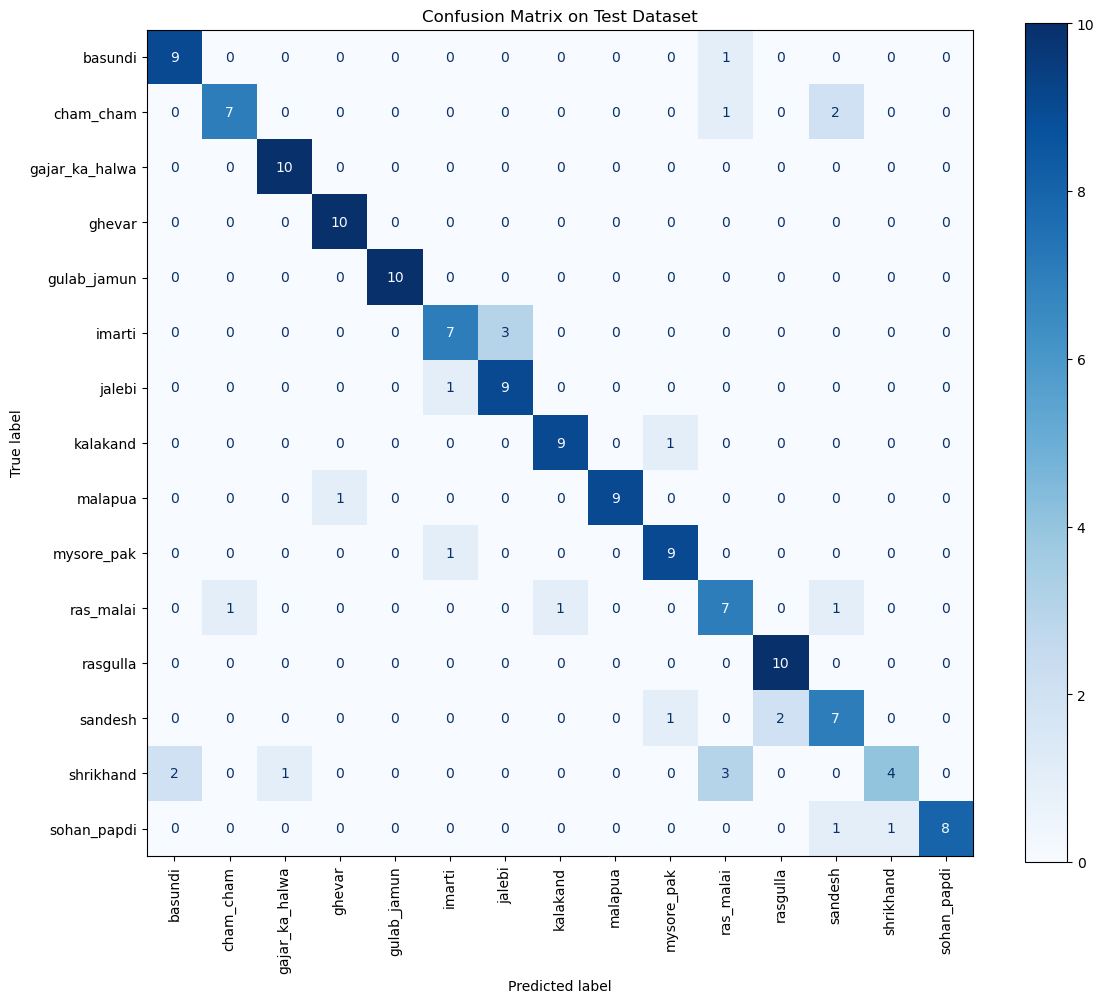


Classification Report:
                precision    recall  f1-score   support

       basundi       0.82      0.90      0.86        10
     cham_cham       0.88      0.70      0.78        10
gajar_ka_halwa       0.91      1.00      0.95        10
        ghevar       0.91      1.00      0.95        10
   gulab_jamun       1.00      1.00      1.00        10
        imarti       0.78      0.70      0.74        10
        jalebi       0.75      0.90      0.82        10
      kalakand       0.90      0.90      0.90        10
       malapua       1.00      0.90      0.95        10
    mysore_pak       0.82      0.90      0.86        10
     ras_malai       0.58      0.70      0.64        10
      rasgulla       0.83      1.00      0.91        10
       sandesh       0.64      0.70      0.67        10
     shrikhand       0.80      0.40      0.53        10
   sohan_papdi       1.00      0.80      0.89        10

      accuracy                           0.83       150
     macro avg       0

In [15]:
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

test_dir = 'test_dataset'
valid_extensions = ('.jpg', '.jpeg', '.png')

y_true = []
y_pred = []

print(f"Starting evaluation on '{test_dir}' directory...")

for cls_name in class_names:
    cls_dir = os.path.join(test_dir, cls_name)
    if not os.path.isdir(cls_dir):
        print(f"Warning: Directory not found for class '{cls_name}'")
        continue
        
    for filename in os.listdir(cls_dir):
        if filename.lower().endswith(valid_extensions):
            filepath = os.path.join(cls_dir, filename)
            
            try:
                image = Image.open(filepath).convert('RGB')
                img_t = transform(image).unsqueeze(0).to(device)
                
                with torch.no_grad():
                    out = model(img_t)
                    top_catid = torch.argmax(out[0])
                    predicted_class = class_names[top_catid.item()]
                    
                y_true.append(cls_name)
                y_pred.append(predicted_class)
                
            except Exception as e:
                print(f"Error processing {filepath}: {e}")

print("Evaluation complete.")

# Calculate and plot confusion matrix
if len(y_true) > 0 and len(y_pred) > 0:
    cm = confusion_matrix(y_true, y_pred, labels=class_names)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    disp.plot(ax=ax, cmap='Blues', xticks_rotation='vertical')
    plt.title("Confusion Matrix on Test Dataset")
    plt.tight_layout()
    plt.show()
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, labels=class_names))
else:
    print("No images were found/processed to generate a confusion matrix.")

## Test Multi-Class Images (composite_class)
Run the model on images containing a mix of sweets to see the top 2 predictions and plot them in figures.


--- Testing on mixed images in: test_dataset/composite class ---
File: gulab_jamun_basundi_3.jpeg | Top 1: ghevar          (59.00%) | Top 2: sandesh         (18.24%)
File: basudi_jalebi_2.jpg  | Top 1: basundi         (49.86%) | Top 2: ras_malai       (11.69%)
File: gulab_jamun_basundi_2.jpeg | Top 1: ras_malai       (22.25%) | Top 2: gulab_jamun     (16.41%)
File: basundi_imarti.jpeg  | Top 1: kalakand        (30.32%) | Top 2: imarti          (19.18%)
File: basundi_jalebi.jpeg  | Top 1: jalebi          (63.52%) | Top 2: shrikhand       (15.24%)
File: gulab_jamun_basundi_4.jpeg | Top 1: gulab_jamun     (74.88%) | Top 2: ras_malai       ( 5.80%)
File: gulab_jamun_basundi.jpeg | Top 1: gulab_jamun     (93.49%) | Top 2: rasgulla        ( 2.38%)
File: basundi_imarti_2.jpg | Top 1: shrikhand       (41.35%) | Top 2: imarti          (29.40%)


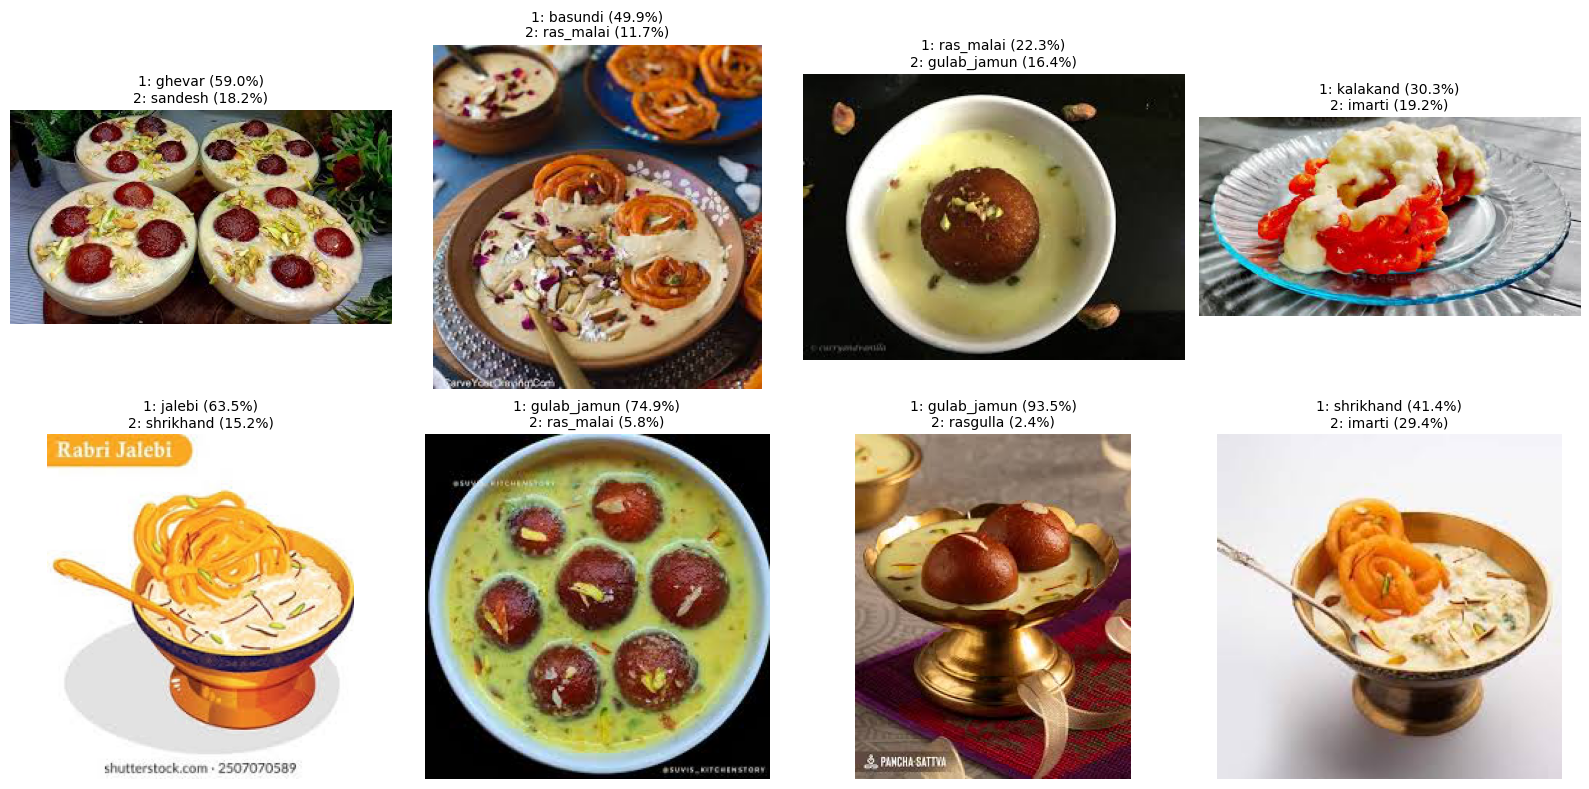

In [20]:
mixed_folder = os.path.join('test_dataset', 'composite class')
print(f"\n--- Testing on mixed images in: {mixed_folder} ---")

results = []

if not os.path.exists(mixed_folder):
    print("Folder not found.")
else:
    for filename in os.listdir(mixed_folder):
        if filename.lower().endswith(valid_extensions):
            filepath = os.path.join(mixed_folder, filename)
            
            try:
                image = Image.open(filepath).convert('RGB')
                img_t = transform(image).unsqueeze(0).to(device)
                
                with torch.no_grad():
                    out = model(img_t)
                    probabilities = torch.nn.functional.softmax(out[0], dim=0)
                    
                    # Get top 2 predictions
                    top_probs, top_catids = torch.topk(probabilities, 2)
                    
                    pred_1 = class_names[top_catids[0].item()]
                    conf_1 = top_probs[0].item() * 100
                    
                    pred_2 = class_names[top_catids[1].item()]
                    conf_2 = top_probs[1].item() * 100
                    
                print(f"File: {filename:20s} | Top 1: {pred_1:15s} ({conf_1:5.2f}%) | Top 2: {pred_2:15s} ({conf_2:5.2f}%)")
                
                # Store the original image and formatted caption for plotting
                caption = f"1: {pred_1} ({conf_1:.1f}%)\n2: {pred_2} ({conf_2:.1f}%)"
                results.append((image, caption))
                
            except Exception as e:
                print(f"Error processing {filepath}: {e}")

    # Display up to 8 images in a single figure
    if results:
        # Limit to max 8 images
        images_to_plot = results[:8]
        num_images = len(images_to_plot)
        
        # Calculate rows and columns (e.g., 2 rows x 4 columns for 8 images)
        cols = min(4, num_images)
        rows = (num_images + cols - 1) // cols
        
        fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
        
        # Flatten axes array for easy iteration, handling cases with 1 row differently
        if rows == 1 and cols == 1:
            axes = [axes]
        elif rows == 1 or cols == 1:
             pass # Already a 1D array
        else:
            axes = axes.flatten()
        
        for i in range(len(axes)):
            if i < num_images:
                img, caption = images_to_plot[i]
                axes[i].imshow(img)
                axes[i].set_title(caption, fontsize=10)
                axes[i].axis('off')
            else:
                axes[i].axis('off') # Hide empty subplots
                
        plt.tight_layout()
        plt.show()